In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/insurance-premium-forecasting-challenge/sample_submission.csv
/kaggle/input/insurance-premium-forecasting-challenge/augmented_test.csv
/kaggle/input/insurance-premium-forecasting-challenge/augmented_train (1).csv


In [2]:
import kagglehub

In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.

insurance_premium_forecasting_challenge_path = kagglehub.competition_download('insurance-premium-forecasting-challenge')

print('Data source import complete.')

Data source import complete.


# Importing All Neccessary Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing processing modules
from sklearn.preprocessing import LabelEncoder,RobustScaler,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
#Importing Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
#importing the performence metrices
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_log_error,mean_absolute_percentage_error,explained_variance_score,max_error
import warnings
warnings.filterwarnings('ignore')
print("Done")

Done


In [5]:
#Loading the dataset
try:
  df_train = pd.read_csv('/kaggle/input/insurance-premium-forecasting-challenge/augmented_train (1).csv')
  df_test = pd.read_csv('/kaggle/input/insurance-premium-forecasting-challenge/augmented_test.csv')
  print('Data Loaded Successfully')
except FileNotFoundError:
  print("Error:File Not Found")

Data Loaded Successfully


# Data Exploration and Handling

In [6]:
#Checking The Size of data
print(f"Size of Training Data:{df_train.shape}")
print(f"Size of Training Data:{df_test.shape}")

Size of Training Data:(1200000, 27)
Size of Training Data:(800000, 26)


In [7]:
#Finding The Columns in Dataset
print('Columns in Training Data')
print(df_train.columns)
print('Columns in Testing Data')
print(df_test.columns)

Columns in Training Data
Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount', 'Financial Index', 'Risk Profile',
       'Income Stability', 'Credit Reliability', 'Regional Code',
       'Policy Weekday'],
      dtype='object')
Columns in Testing Data
Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Financial Index', 'Risk Profile', 'Income

In [8]:
print('Training Data')
df_train.head()

Training Data


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Financial Index,Risk Profile,Income Stability,Credit Reliability,Regional Code,Policy Weekday
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,No,Weekly,House,2869.000000,37.454012,0.585854,9653.464185,290521.0,RC044,6
1,1,39.0,Female,316780.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,Yes,Monthly,House,1476.634221,95.071431,0.877287,293718.014356,481636.0,RC039,-1
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,Yes,Weekly,House,567.000000,73.199394,NaN,24813.980040,NaN,RC012,6
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,Yes,Daily,Apartment,765.000000,59.865848,-0.059436,144333.092133,134689.0,RC007,1
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,Yes,Weekly,House,2022.000000,15.601864,0.272688,40214.578097,357604.0,RC067,2


In [9]:
print('Testing Data')
df_test.head()

Testing Data


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Financial Index,Risk Profile,Income Stability,Credit Reliability,Regional Code,Policy Weekday
0,1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,...,Poor,Yes,Weekly,House,11.505457,NaN,2141.172595,NaN,RC040,6
1,1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,...,Good,Yes,Rarely,Apartment,60.906654,0.126385,128618.702813,285156.0,RC010,0
2,1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,...,Average,Yes,Monthly,Condo,13.339096,2.135153,15176.855203,670761.0,RC091,1
3,1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,...,Poor,Yes,Daily,House,24.058962,0.728533,29265.675710,592900.0,RC075,2
4,1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,...,Average,No,Weekly,House,32.713906,1.649693,11241.845284,570025.0,RC078,3


In [10]:
print('Training Data Info')
df_train.info()

Training Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Durat

In [11]:
print('Statistics of Training Data:')
print(df_train.describe())

Statistics of Training Data:
                 id           Age  Annual Income  Number of Dependents  \
count  1.200000e+06  1.181295e+06   1.155051e+06          1.090328e+06   
mean   5.999995e+05  4.114556e+01   4.683944e+04          2.009934e+00   
std    3.464103e+05  1.353995e+01   9.403841e+04          1.417338e+00   
min    0.000000e+00  1.800000e+01   1.000000e+00          0.000000e+00   
25%    2.999998e+05  3.000000e+01   8.805000e+03          1.000000e+00   
50%    5.999995e+05  4.100000e+01   2.513500e+04          2.000000e+00   
75%    8.999992e+05  5.300000e+01   4.708800e+04          3.000000e+00   
max    1.199999e+06  6.400000e+01   1.000000e+06          4.000000e+00   

       Health Score  Previous Claims   Vehicle Age  Credit Score  \
count  1.125924e+06    835971.000000  1.199994e+06  1.062118e+06   
mean   2.561391e+01         1.002689  9.569889e+00  6.086953e+02   
std    1.220346e+01         0.982840  5.776189e+00  1.542403e+02   
min    2.012237e+00         0.00

In [12]:
print('Statistics of Testing Data:')
print(df_test.describe())

Statistics of Testing Data:
                 id            Age   Annual Income  Number of Dependents  \
count  8.000000e+05  787511.000000   770140.000000         726870.000000   
mean   1.600000e+06      41.136440    46935.579843              2.009337   
std    2.309403e+05      13.537829    94295.182743              1.415241   
min    1.200000e+06      18.000000        2.000000              0.000000   
25%    1.400000e+06      30.000000     8844.000000              1.000000   
50%    1.600000e+06      41.000000    25168.000000              2.000000   
75%    1.799999e+06      53.000000    47141.500000              3.000000   
max    1.999999e+06      64.000000  1000000.000000              4.000000   

        Health Score  Previous Claims    Vehicle Age   Credit Score  \
count  750551.000000    557198.000000  799997.000000  708549.000000   
mean       25.613036         1.004873       9.571891     608.657609   
std        12.206882         0.982803       5.772200     154.356071   
min

In [13]:
print('Missing Values in Training Data')
print(df_train.isnull().sum())

Missing Values in Training Data
id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
Financial Index              0
Risk Profile            195341
Income Stability         44949
Credit Reliability      137882
Regional Code                0
Policy Weekday               0
dtype: int64


In [14]:
print("Percentage of missing values in each columns:")
(df_train.isna().sum()/len(df_train))*100

Percentage of missing values in each columns:


id                       0.000000
Age                      1.558750
Gender                   0.000000
Annual Income            3.745750
Marital Status           1.544083
Number of Dependents     9.139333
Education Level          0.000000
Occupation              29.839583
Health Score             6.173000
Location                 0.000000
Policy Type              0.000000
Previous Claims         30.335750
Vehicle Age              0.000500
Credit Score            11.490167
Insurance Duration       0.000083
Policy Start Date        0.000000
Customer Feedback        6.485333
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
Premium Amount           0.000000
Financial Index          0.000000
Risk Profile            16.278417
Income Stability         3.745750
Credit Reliability      11.490167
Regional Code            0.000000
Policy Weekday           0.000000
dtype: float64

In [15]:
print('Missing Values in Testing Data')
print(df_test.isnull().sum())

Missing Values in Testing Data
id                           0
Age                      12489
Gender                       0
Annual Income            29860
Marital Status           12336
Number of Dependents     73130
Education Level              0
Occupation              239125
Health Score             49449
Location                     0
Policy Type                  0
Previous Claims         242802
Vehicle Age                  3
Credit Score             91451
Insurance Duration           2
Policy Start Date            0
Customer Feedback        52276
Smoking Status               0
Exercise Frequency           0
Property Type                0
Financial Index              0
Risk Profile            129710
Income Stability         29860
Credit Reliability       91451
Regional Code                0
Policy Weekday               0
dtype: int64


In [16]:
print("Percentage of missing values in each columns:")
(df_test.isna().sum()/len(df_test))*100

Percentage of missing values in each columns:


id                       0.000000
Age                      1.561125
Gender                   0.000000
Annual Income            3.732500
Marital Status           1.542000
Number of Dependents     9.141250
Education Level          0.000000
Occupation              29.890625
Health Score             6.181125
Location                 0.000000
Policy Type              0.000000
Previous Claims         30.350250
Vehicle Age              0.000375
Credit Score            11.431375
Insurance Duration       0.000250
Policy Start Date        0.000000
Customer Feedback        6.534500
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
Financial Index          0.000000
Risk Profile            16.213750
Income Stability         3.732500
Credit Reliability      11.431375
Regional Code            0.000000
Policy Weekday           0.000000
dtype: float64

In [17]:
print('Duplicate Values in Training Data')
print(df_train.duplicated().sum())

Duplicate Values in Training Data
0


In [18]:
print('Duplicate Values in Testing Data')
print(df_test.duplicated().sum())

Duplicate Values in Testing Data
0


In [19]:
#Converting the Date column to datetime dtype
for df in [df_train,df_test]:
  df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'])

In [20]:
#Diffrentiating the Numerical and Categorical Columns
numerical_cols = df_train.select_dtypes(include=np.number).columns
categorical_cols = df_train.select_dtypes(exclude=np.number).columns

In [21]:
#Filling the Missing Values in Training Data
for col in numerical_cols:
  df_train[col] = df_train[col].fillna(df_train[col].median())
for col in categorical_cols:
  df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

In [22]:
numerical_cols_test = df_test.select_dtypes(include=np.number).columns
categorical_cols_test = df_test.select_dtypes(exclude=np.number).columns

In [23]:
#Filling the Missing Values in Testing Data
for col in numerical_cols_test:
  df_test[col] = df_test[col].fillna(df_test[col].median())
for col in categorical_cols_test:
  df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

In [24]:
print('Missing Values in Training Data')
print(df_train.isnull().sum())
print('Missing Values in Testing Data')
print(df_test.isnull().sum())

Missing Values in Training Data
id                      0
Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Occupation              0
Health Score            0
Location                0
Policy Type             0
Previous Claims         0
Vehicle Age             0
Credit Score            0
Insurance Duration      0
Policy Start Date       0
Customer Feedback       0
Smoking Status          0
Exercise Frequency      0
Property Type           0
Premium Amount          0
Financial Index         0
Risk Profile            0
Income Stability        0
Credit Reliability      0
Regional Code           0
Policy Weekday          0
dtype: int64
Missing Values in Testing Data
id                      0
Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Occupation              0
Health Score  

In [25]:
df_train['Income_per_Dependent'] = df_train['Annual Income'] / (df_train['Number of Dependents'] + 1)
df_train['Claims_per_Year'] = df_train['Previous Claims'] / df_train['Insurance Duration']
df_train['Credit_per_Income'] = df_train['Credit Score'] / (df_train['Annual Income'] + 1)

In [26]:
df_test['Income_per_Dependent'] = df_test['Annual Income'] / (df_test['Number of Dependents'] + 1)
df_test['Claims_per_Year'] = df_test['Previous Claims'] / df_test['Insurance Duration']
df_test['Credit_per_Income'] = df_test['Credit Score'] / (df_test['Annual Income'] + 1)

In [27]:
for df in [df_train,df_test]:
  df['Policy Year'] = df['Policy Start Date'].dt.year
  df['Policy Month'] = df['Policy Start Date'].dt.month
  df['Policy Day'] = df['Policy Start Date'].dt.day
  df['Policy Day of Week'] = df['Policy Start Date'].dt.dayofweek
  df['Policy Quarter'] = df['Policy Start Date'].dt.quarter
  df['Policy Day of Year'] = df['Policy Start Date'].dt.dayofyear
  df['Policy Week of Year'] = df['Policy Start Date'].dt.isocalendar().week
  df = df.drop(labels = 'Policy Start Date',axis = 1)

In [28]:
#Storing the id for further use
test_id = df_test['id']

In [29]:
df_train = df_train.drop(labels = 'id',axis = 1)
df_test = df_test.drop(labels = 'id',axis = 1)

# Data Visualization

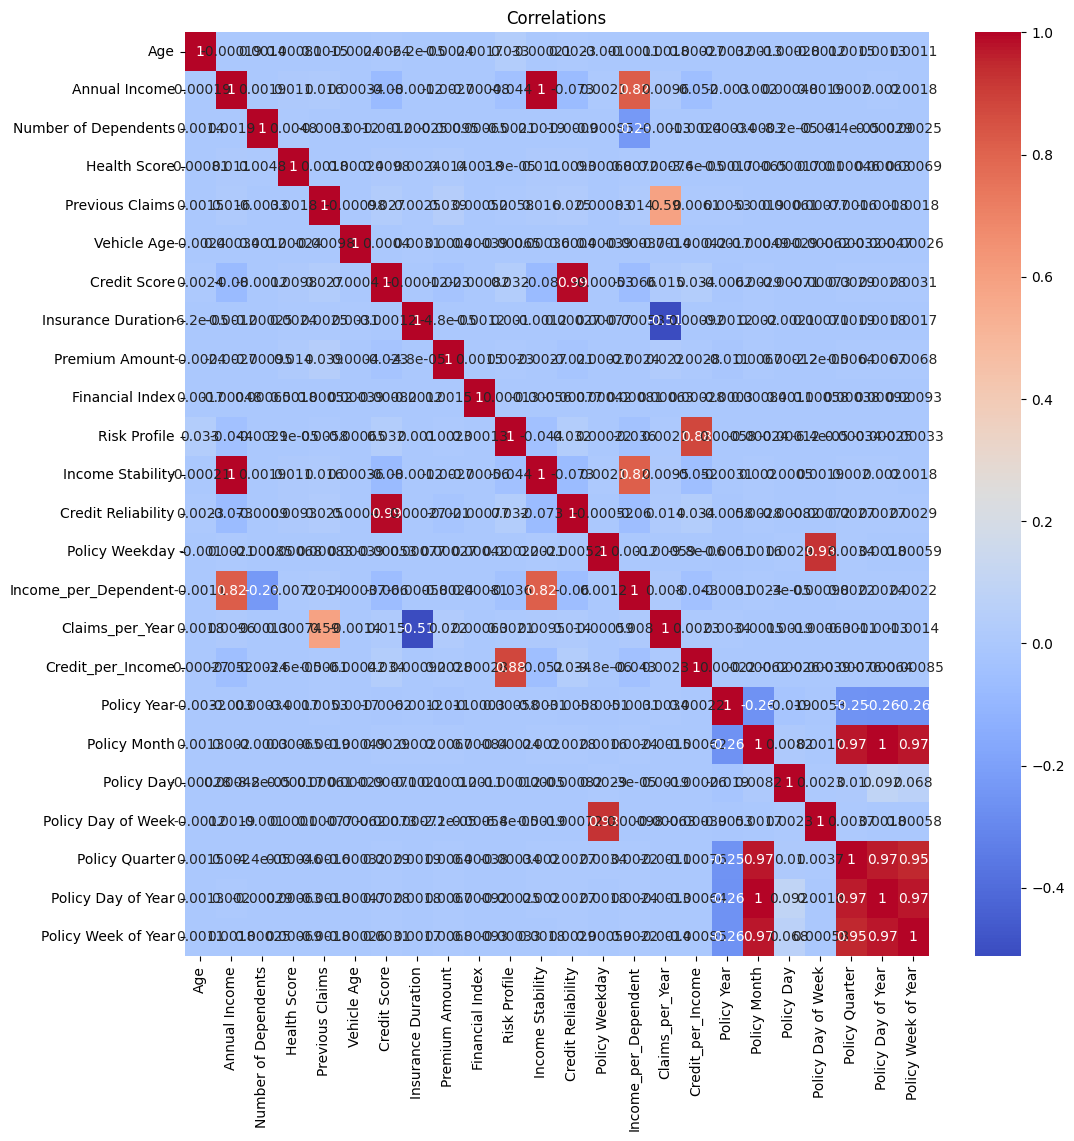

In [30]:
plt.figure(figsize = (12,12))
sns.heatmap(df_train.corr(numeric_only = True),annot = True,cmap='coolwarm')
plt.title("Correlations")
plt.show()

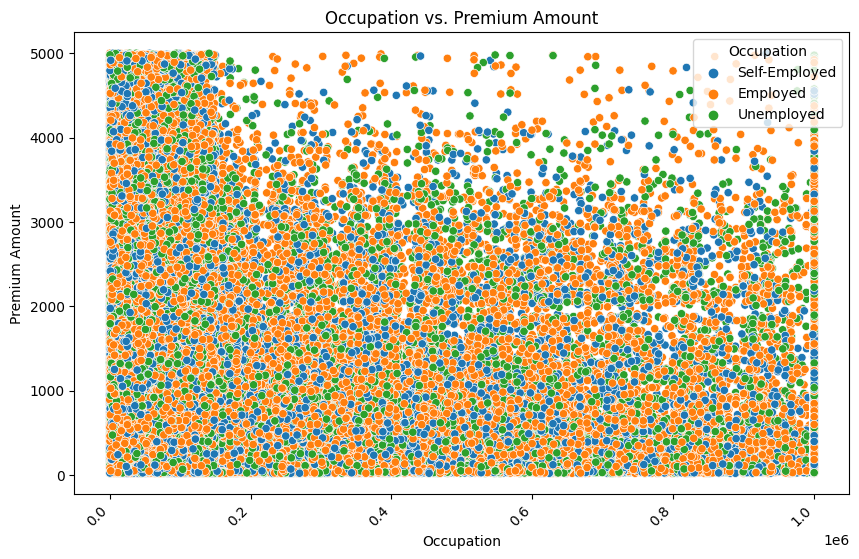

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income',y='Premium Amount',hue='Occupation', data=df_train)
plt.title('Occupation vs. Premium Amount')
plt.xlabel('Occupation')
plt.ylabel('Premium Amount')
plt.xticks(rotation=45, ha='right')
plt.show()

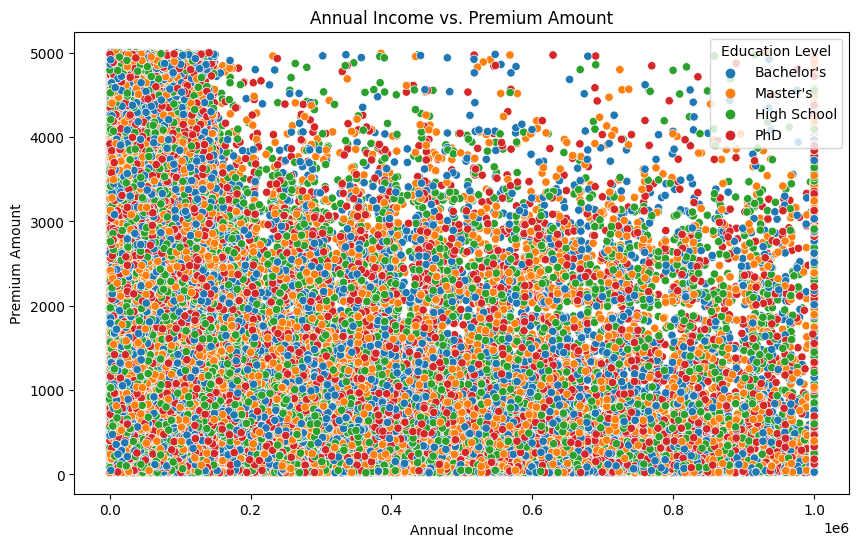

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income', y='Premium Amount',hue='Education Level' ,data=df_train)
plt.title('Annual Income vs. Premium Amount')
plt.xlabel('Annual Income')
plt.ylabel('Premium Amount')
plt.show()

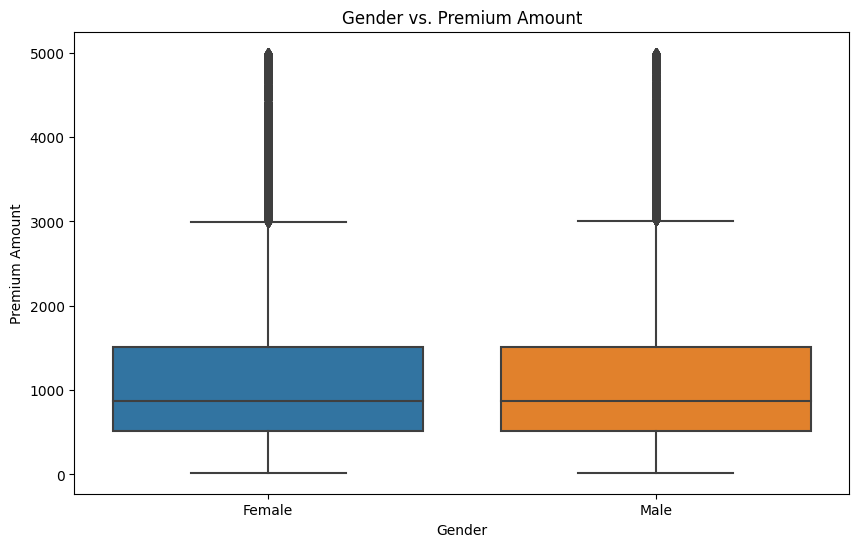

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Premium Amount', data=df_train)
plt.title('Gender vs. Premium Amount')
plt.xlabel('Gender')
plt.ylabel('Premium Amount')
plt.show()

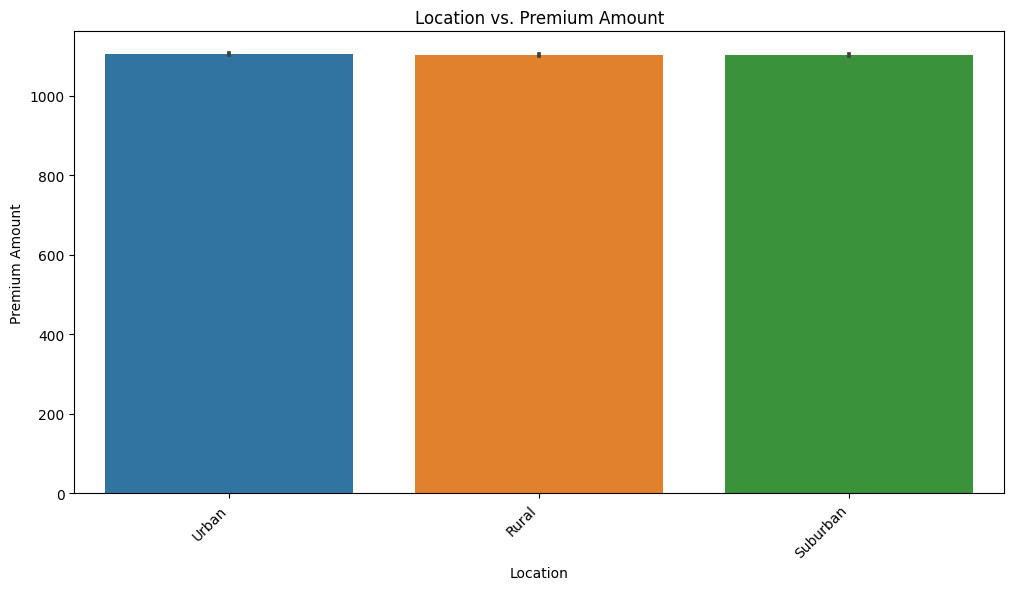

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Location', y='Premium Amount', data=df_train)
plt.title('Location vs. Premium Amount')
plt.xlabel('Location')
plt.ylabel('Premium Amount')
plt.xticks(rotation=45, ha='right')
plt.show()

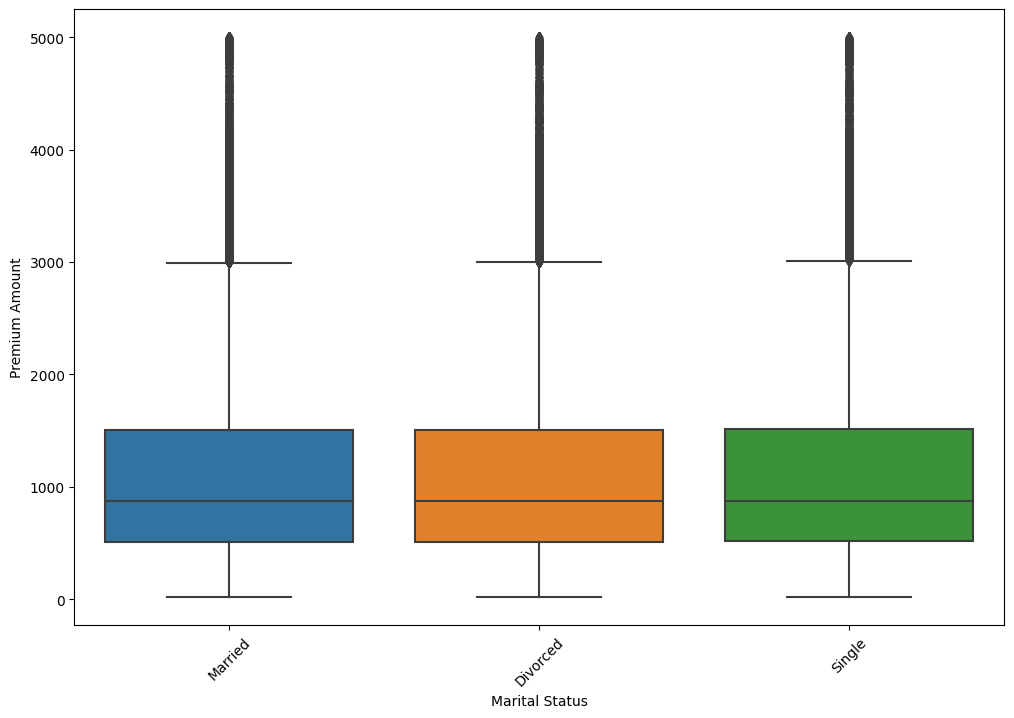

In [35]:
plt.figure(figsize = (12, 8))
sns.boxplot(x = 'Marital Status', y = 'Premium Amount', data = df_train)
plt.xticks(rotation = 45)
plt.show()

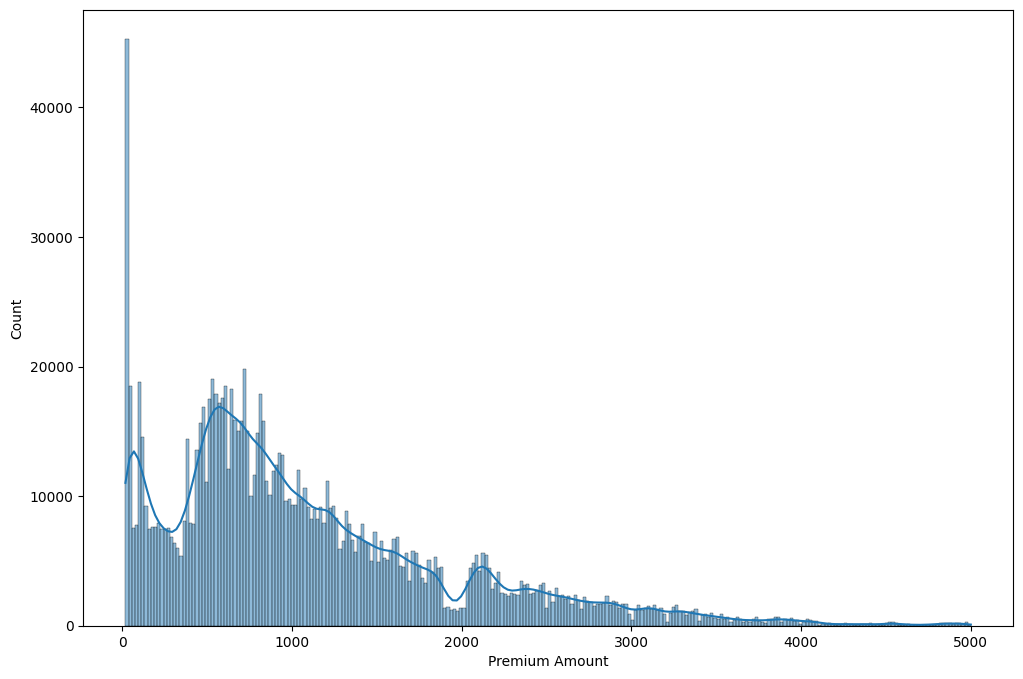

In [36]:
plt.figure(figsize = (12, 8))
sns.histplot(df_train['Premium Amount'], kde = True)
plt.show()

# Model Training

In [37]:
numeric_features = df_train.select_dtypes(include=['int64', 'float64']).drop('Premium Amount', axis=1).columns.tolist()
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OrdinalEncoder(), categorical_features)
    ])

In [39]:
X = df_train.drop('Premium Amount', axis=1)
y = df_train['Premium Amount']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
models = {
    'Linear Regression': LinearRegression(),
    'CatBoost': CatBoostRegressor(iterations=500,
        depth=8,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=0,
        random_seed=42,
        ),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators = 500, max_depth = 8, learning_rate = 0.05, subsample = 0.8, colsample_bytree = 0.8),
    'LGBM': LGBMRegressor(objective='regression', random_state=42, n_estimators = 500, max_depth = 8, learning_rate = 0.05,verbose=-1),
    'Ridge': Ridge()
}

In [42]:
for name,model in models.items():
  pipeline = Pipeline(steps=[('preprocessor',preprocessor),('model',model)])
  log_regressor = TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)
  log_regressor.fit(X_train, y_train)
  y_pred = log_regressor.predict(X_test)
  score = np.sqrt(mean_squared_log_error(y_test,y_pred))
  print(f"Model: {name}")
  print(f"RMSLE: {score:.4f}")

Model: Linear Regression
RMSLE: 1.0938
Model: CatBoost
RMSLE: 1.0617
Model: XGBoost
RMSLE: 1.0620
Model: LGBM
RMSLE: 1.0608
Model: Ridge
RMSLE: 1.0938


In [43]:
selected_model =  XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators = 500, max_depth = 8, learning_rate = 0.05, subsample = 0.8, colsample_bytree = 0.8)

**Reason:**We chose the XGBoost model for our regression task as it achieved the approx Root Mean Squared Logarithmic Error among all the models tested. RMSLE is particularly suitable when the target variable has a wide range or when we want to penalize underestimations more than overestimations and when the data is skewed. A proper RMSLE indicates that the model is more accurate in predicting values relative to their scale, making XG Boost the most reliable model for our use case.Since We Use Logarithmic Transformer Regressor to find the least rmsle value.

In [44]:
pipeline_final = Pipeline(steps=[('preprocessor',preprocessor),('model',selected_model)])

In [45]:
log_regressor = TransformedTargetRegressor(regressor=pipeline_final, func=np.log1p, inverse_func=np.expm1)

In [46]:
log_regressor.fit(X, y)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       RobustScaler(),
                                                                                       ['Age',
                                                                                        'Annual '
                                                                                        'Income',
                                                                                        'Number '
                                                                                        'of '
                                                                                        'Dependents',
                                                                                        'Health '
                                                                                        'Score',
                                                                                        'Previous '
                                                                                        'Claims',
                                                                                        'Vehicle '
                                                                                        'Age',
                                                                                        'Credit '
                                                                                        'Score',
                                                                                        'Insurance '
                                                                                        'Duration',
                                                                                        'Financial '
                                                                                        'Index',
                                                                                        'Risk '
                                                                                        'Profile',
                                                                                        'Income...
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=0.05,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=8,
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=500,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None,
                                  

In [47]:
df_test['Premium Amount'] = log_regressor.predict(df_test)

In [48]:
submission_df = pd.DataFrame({'id': test_id, 'Premium Amount': df_test['Premium Amount']})
submission_df.to_csv('submission(log_regressor(Xgb(1))).csv', index=False)
print("Submission Csv:\n",submission_df.head())

Submission Csv:
         id  Premium Amount
0  1200000      717.896790
1  1200001      344.417297
2  1200002      778.412354
3  1200003      801.862000
4  1200004      743.907654


# Conclusion:
The model used for predicting the Premium Amount is a XG Boost Regressor, chosen for its efficiency and performance on large datasets. Given that the dataset is skewed, with most values concentrated in a specific range, we opted for the Root Mean Squared Logarithmic Error (RMSLE) as the primary evaluation metric.

RMSLE is more suitable in this case than RMSE because it handles skewed distributions better by penalizing underestimates more than overestimates and reducing the impact of large target values. Additionally, using RMSLE helps ensure that the model generalizes well, preventing both overfitting and underfitting.

To streamline preprocessing and model training, we constructed a pipeline and Logarithmic Transformers  which automates data transformations and prediction, ensuring consistency and reproducibility throughout the workflow.